In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ----------------------
# Config
# ----------------------
g = 9.81            # gravity (m/s^2)
H = 1.0             # mean fluid depth (m)
T = 5.0             # total simulation time
Nx, Ny = 64, 64
Nt = 2500
Lx, Ly = 1.0, 1.0   # domain size
SENSORS = 100
NOISE_MODE = "max"  # "std" or "max"
NOISE_DIV = 10.0
RNG_SEED = 42
SAVE_PATH = "swe2d_periodic_dataset.npz"
DTYPE = np.float32

In [4]:
# ----------------------
# Discretization
# ----------------------
x = np.linspace(0, Lx, Nx, dtype=DTYPE)
y = np.linspace(0, Ly, Ny, dtype=DTYPE)
t = np.linspace(0, T, Nt, dtype=DTYPE)
dx = x[1] - x[0]
dy = y[1] - y[0]
dt = t[1] - t[0]
X, Y = np.meshgrid(x, y, indexing='ij')

In [5]:
# ----------------------
# CFL stability check (conservative for FB scheme)
# Wave speed c = sqrt(g H)
# Require:  c * dt * sqrt( (1/dx)^2 + (1/dy)^2 ) <= 1
# ----------------------
c = np.sqrt(g * H)
courant = c * dt * np.sqrt((1.0/dx**2) + (1.0/dy**2))
if courant > 1.0 + 1e-12:
    raise RuntimeError(
        f"Unstable explicit step: Courant = {courant:.4f} (> 1). "
        f"Try smaller dt or coarser grid."
    )
print(f"[CFL] c={c:.5f}, dt={float(dt):.5e}, dx={float(dx):.5e}, dy={float(dy):.5e}, Courant={courant:.6f} --> OK")

[CFL] c=3.13209, dt=2.00080e-03, dx=1.58730e-02, dy=1.58730e-02, Courant=0.558334 --> OK


In [6]:
# ----------------------
# Allocate & initial condition (IC-driven waves)
# eta: free-surface displacement; u, v: depth-averaged velocities
# Use a smooth Gaussian bump in eta; start with u=v=0
# ----------------------
eta = np.zeros((Nx, Ny, Nt), dtype=DTYPE)
u   = np.zeros((Nx, Ny, Nt), dtype=DTYPE)
v   = np.zeros((Nx, Ny, Nt), dtype=DTYPE)

# Gaussian bump for eta at t=0
x0, y0 = 0.5 * Lx, 0.5 * Ly
sigma = 0.08 * min(Lx, Ly)
eta0 = np.exp(-(((X - x0)**2 + (Y - y0)**2) / (2.0 * sigma**2))).astype(DTYPE)

eta[:, :, 0] = eta0
# u[:,:,0] and v[:,:,0] are already zero

In [7]:
# ----------------------
# Helpers: centered derivatives with periodic wrap
# ----------------------
def ddx(F, dx):
    # (F_{i+1} - F_{i-1}) / (2 dx) with periodic boundaries
    return (np.roll(F, -1, axis=0) - np.roll(F, 1, axis=0)) / (2.0 * dx)

def ddy(F, dy):
    return (np.roll(F, -1, axis=1) - np.roll(F, 1, axis=1)) / (2.0 * dy)


In [8]:
# ----------------------
# Time stepping (Forward-Backward)
#   u^{n+1} = u^n - dt * g * d(eta^n)/dx
#   v^{n+1} = v^n - dt * g * d(eta^n)/dy
#   eta^{n+1} = eta^n - dt * H * ( d(u^{n+1})/dx + d(v^{n+1})/dy )
# ----------------------
for n in range(Nt - 1):
    etan = eta[:, :, n]
    un   = u[:, :, n]
    vn   = v[:, :, n]

    detadx = ddx(etan, dx)
    detady = ddy(etan, dy)

    u_np1 = un - dt * g * detadx
    v_np1 = vn - dt * g * detady

    div_np1 = ddx(u_np1, dx) + ddy(v_np1, dy)
    eta_np1 = etan - dt * H * div_np1

    u[:, :, n+1]   = u_np1
    v[:, :, n+1]   = v_np1
    eta[:, :, n+1] = eta_np1

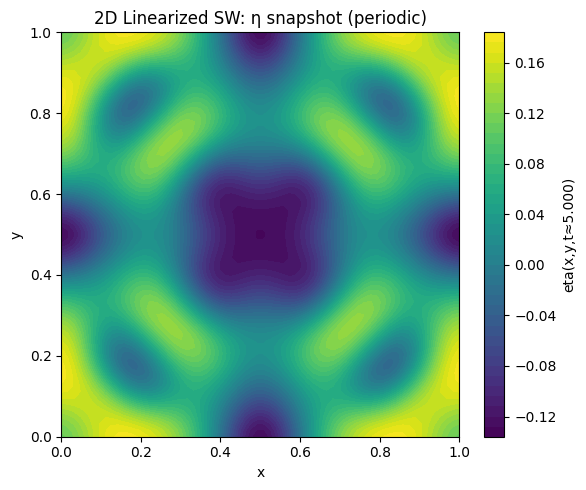

η min[0], max[0] = 1.08485515e-17 0.9902064    η min[mid], max[mid] = -0.1282199 0.17950778


In [15]:
# ----------------------
# Quick visualization (middle frame of eta)
# ----------------------
frame = 2499
plt.figure(figsize=(6,5))
cs = plt.contourf(X, Y, eta[:, :, frame], levels=50, cmap='viridis')
plt.colorbar(cs, label=f"eta(x,y,t≈{t[frame]:.3f})")
plt.title("2D Linearized SW: η snapshot (periodic)")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

mins = [eta[:, :, k].min() for k in range(Nt)]
maxs = [eta[:, :, k].max() for k in range(Nt)]
print("η min[0], max[0] =", mins[0], maxs[0],
      "   η min[mid], max[mid] =", mins[frame], maxs[frame])

In [16]:
# ----------------------
# Sensor sampling & noise (on η; extend to u,v if desired)
# ----------------------
rng = np.random.default_rng(RNG_SEED)
all_ij = np.array([(i, j) for i in range(Nx) for j in range(Ny)], dtype=np.int32)
sel_idx = rng.choice(all_ij.shape[0], size=SENSORS, replace=False)
sel_ij  = all_ij[sel_idx]                           # (SENSORS, 2)
sel_xy  = np.stack([x[sel_ij[:,0]], y[sel_ij[:,1]]], axis=1)  # (SENSORS, 2)

eta_sensor_clean = np.stack([eta[i, j, :] for (i, j) in sel_ij], axis=0)  # (SENSORS, Nt)

if NOISE_MODE == "std":
    sigma = np.std(eta_sensor_clean)
elif NOISE_MODE == "max":
    sigma = np.max(np.abs(eta_sensor_clean))
else:
    raise ValueError("NOISE_MODE must be 'std' or 'max'")

noise_std = (sigma / NOISE_DIV).astype(DTYPE) if isinstance(sigma, np.ndarray) else DTYPE(sigma / NOISE_DIV)
eta_sensor_noisy = eta_sensor_clean + rng.normal(scale=float(noise_std),
                                                 size=eta_sensor_clean.shape).astype(DTYPE)

In [17]:
# ----------------------
# Save everything (compressed)
# ----------------------
param_names = np.array([
    "g","H","T","Nx","Ny","Nt","Lx","Ly","dx","dy","dt"
], dtype='<U16')
params = np.array([g, H, T, Nx, Ny, Nt, Lx, Ly, dx, dy, dt], dtype=np.float64)

np.savez_compressed(
    SAVE_PATH,
    # fields
    eta=eta.astype(DTYPE),      # (Nx, Ny, Nt)
    u=u.astype(DTYPE),          # (Nx, Ny, Nt)
    v=v.astype(DTYPE),          # (Nx, Ny, Nt)
    # coords
    x=x, y=y, t=t,
    X=X.astype(DTYPE), Y=Y.astype(DTYPE),
    # meta
    params=params,
    param_names=param_names,
    bc=np.array(["periodic"]),
    rng_seed=np.array([RNG_SEED], dtype=np.int64),
    # sensors
    sensors_idx=sel_ij,                 # (SENSORS, 2) grid indices
    sensors_xy=sel_xy.astype(DTYPE),    # (SENSORS, 2)
    eta_sensor_clean=eta_sensor_clean.astype(DTYPE),
    eta_sensor_noisy=eta_sensor_noisy.astype(DTYPE),
    noise_mode=np.array([NOISE_MODE]),
    noise_div=np.array([NOISE_DIV], dtype=np.float32),
)

print(f"[SAVE] Wrote dataset to: {SAVE_PATH}")
print(f"      eta shape: {eta.shape}, u/v shape: {u.shape}, sensors: {SENSORS}, noise σ ≈ {float(noise_std):.4g}")

[SAVE] Wrote dataset to: swe2d_periodic_dataset.npz
      eta shape: (64, 64, 2500), u/v shape: (64, 64, 2500), sensors: 100, noise σ ≈ 0.09902
